In [1]:
%load_ext autoreload
%autoreload 2

import yaml
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import constants as const
from phidl import quickplot as qp
from phidl import Device
from phidl import CrossSection
from phidl import Path
import phidl.geometry as pg
import phidl.routing as pr
import phidl.path as pp
import pprint
import datetime
import os

In [2]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd() / 'util/'))
import qubit_templates
from qubit_templates import *
from functions import *

# Date Check

In [3]:
dt=datetime.datetime.now()
dt2 = dt.strftime('%Y%m%d%H%M')
print("now is "+dt2 )
dt_date=dt.strftime('%Y%m%d')
# print("dt_date is "+dt_date)
date=dt.strftime('%m%d')

now is 202602060930


# Read configuration file

In [4]:
Username="nakazono"

#テンポラリーかどうか(保険)
temp=False

wafertype = "sapphire"#"sapphire" # silicon or sapphire
JJtype = "manhattan" # manhattan or dolan
Squid = False
Bandage = True
EB_marker = True
one_step =False

galvanic=False

output_folder="output/"+dt_date+"/"
print("output_folder is "+output_folder)
os.makedirs(output_folder,exist_ok=True)

#outname = "ICEPP_"+Username+"_"+dt_date+ wafertype + "_" + JJtype

#for Takeda rules
outname = "ICEPP_"+Username+"_"+dt_date

if JJtype == "manhattan":
    outname += "mh"
else:
    outname += "dl"
if Bandage:
    outname += "bd" 
if Squid:
    outname += "sq" 
    
if wafertype=="sapphire":
    outname +="sp"
else:
    outname +="si"
if one_step==True:
    outname += "1step"
else:
    outname += "2step"
if temp:
    outname += "_temp"
print(outname)


config = load_config( f"config/common.yaml" )
globals().update(config)
qubit_templates.__dict__.update(config)

config = load_config( f"config/{JJtype}_3D_{wafertype}.yaml" )
globals().update(config)
qubit_templates.__dict__.update(config)

output_folder is output/20260206/
ICEPP_nakazono_20260206mhbdsp2step


# Wafer design

In [5]:
wafer = device_Wafer(inch = 4)

# Chip design

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


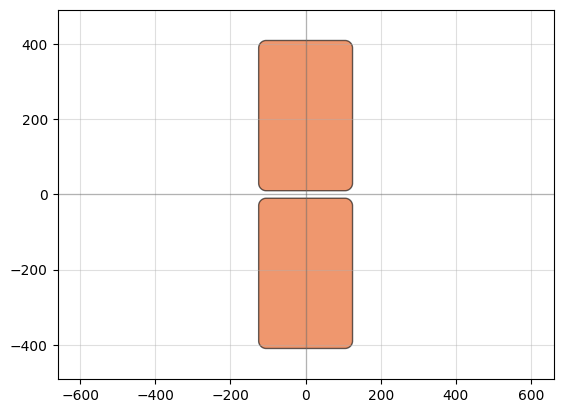

In [6]:
chipdesign = Device('chipdesign')

PAD=Device('PAD')
rectangle = pg.rectangle(( Pad_width, Pad_height), Pad_layer)
rectangle.polygons[0].fillet( Pad_rounding )
PAD.add_ref( rectangle ).movex(0).movey(0.5*Pad_gap)
PAD.add_ref( rectangle ).mirror(p1 = (0, 0), p2 = (200, 0)).movex(0).movey(-0.5*Pad_gap)
PAD.center = (0, 0)

chipdesign.add_ref(PAD)

# Quickplot the imported design
qp(chipdesign)

# Josephson Junction

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


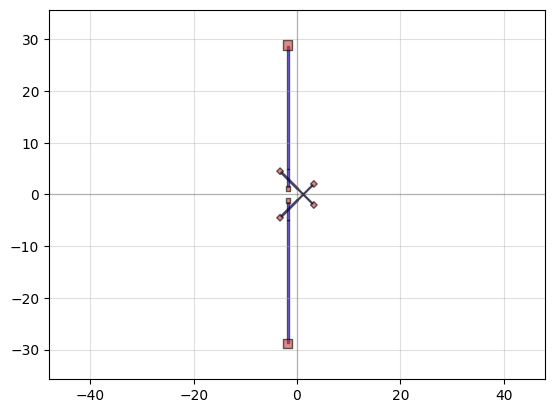

In [7]:
# JJ = device_JJ(width = 0.3, JJtype = "manhattan", squid = True, bandage = False)
# JJ = device_JJ(width = 0.3, JJtype = "manhattan", squid = False, bandage = False)
# JJ = device_JJ(width = 0.135, JJtype = "manhattan", squid = True, bandage = True)
JJ = device_JJ(width = 0.2, JJtype = "manhattan", squid = False, bandage = True,Pad_gap=40)
#JJ = device_JJ(width = 1.0, JJtype = "dolan", squid = True, bandage = False)
# JJ = device_JJ(width = 1.0, JJtype = "dolan", squid = False, bandage = False)
# JJ = device_JJ(width = 1.0, JJtype = "dolan", squid = True, bandage = True)
# JJ = device_JJ(width = 1.0, JJtype = "dolan", squid = False, bandage = True)
qp(JJ)


Xパラメータ : [[0.15, 0.155, 0.16, 0.165, 0.17, 0.175, 0.2], [0.15, 0.155, 0.16, 0.165, 0.17, 0.175, 0.2]]
Yパラメータ : [[20, 100, 20, 100], [20, 100, 20, 100]]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


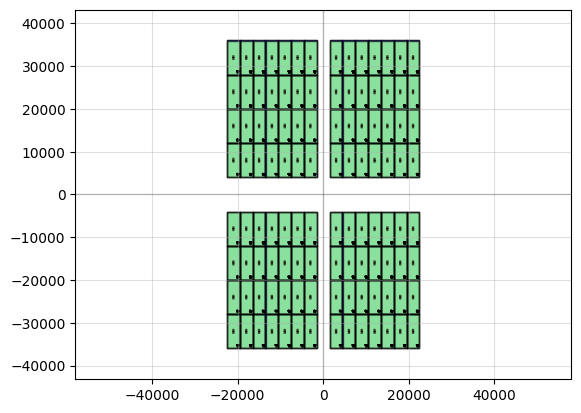

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


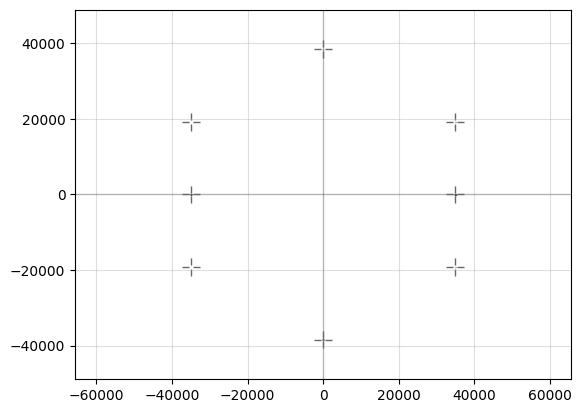

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


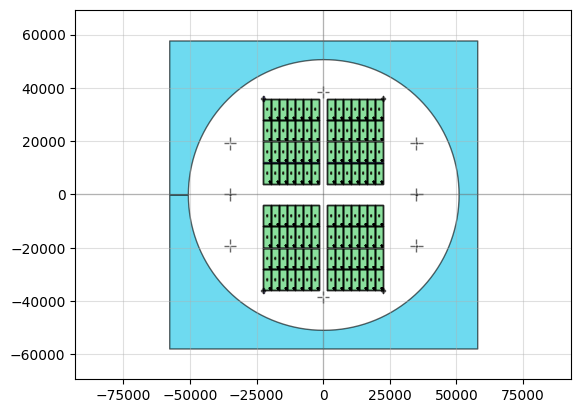

In [8]:
wafer = device_Wafer(inch = 4)

#ここの変数を変える
x_variable="Grid_jj_width"
y_variable="Grid_pad_gap"

def base_custom_chip(params):
    """
    パラメータ辞書(params)に基づいてチップを描画するコア関数。
    この関数は具体的な描画ロジックのみを担当し、再利用性を高める。
    """
    # 辞書から各パラメータを取得。存在しない場合はYAMLからのデフォルト値を使用。
    #　　この後のcreate_chip_blockでGrid...として選択したものが選ばれる。選ばれなかったものはデフォルト

    pad_width = params.get('Grid_pad_width', Pad_width)
    pad_height = params.get('Grid_pad_height', Pad_height)
    pad_gap = params.get('Grid_pad_gap', Pad_gap)
    jj_width = params.get('Grid_jj_width', 0.2)
    finger_width = params.get('Grid_finger_width', 0.15) # Dolan用

    chip=Device('Chip')
    
  

    # --- パッド生成 ---
    PAD = Device('PAD')
    rectangle = pg.rectangle((pad_width, pad_height), Pad_layer)
    rectangle.polygons[0].fillet(Pad_rounding)
    PAD.add_ref(rectangle).movey(0.5 * pad_gap)
    PAD.add_ref(rectangle).mirror(p1=(0, 0), p2=(1, 0)).movey(-0.5 * pad_gap)
    PAD.center = (0, 0)
    chip.add_ref(PAD)

    # --- galvanic contact用design追加 ---
    if galvanic:
        galv=Device('Gal')
        rectangle = pg.rectangle((galvanic_width, galvanic_height), galvanic_layer)
        galv.add_ref( rectangle ).movex(0).movey(0.5*galvanic_gap)
        galv.add_ref( rectangle ).mirror(p1 = (0, 0), p2 = (200, 0)).movex(0).movey(-0.5*galvanic_gap)
        galv.center = (0, 0)
        chip.add_ref(galv)

    # --- JJ生成 ---
    if JJtype == "dolan":
        JJ_squid = device_JJ(bridge_width=jj_width, finger_width=finger_width, JJtype=JJtype, squid=True, bandage=Bandage, photolitho=False,Pad_gap=pad_gap)
        JJ = device_JJ(bridge_width=jj_width, finger_width=finger_width, JJtype=JJtype, squid=False, bandage=Bandage, photolitho=False,Pad_gap=pad_gap)
    else: # manhattan
        JJ_squid = device_JJ(width=jj_width, JJtype=JJtype, squid=True, bandage=Bandage, photolitho=False,Pad_gap=pad_gap)
        JJ = device_JJ(width=jj_width, JJtype=JJtype, squid=False, bandage=Bandage, photolitho=False,Pad_gap=pad_gap)

    if Squid:
        chip.add_ref(JJ_squid)
    else:
        chip.add_ref(JJ)

    # --- テキストラベル生成 ---
    text_label = dt_date+f'\n'
    text_label += '\n'.join([f'{k}: {v}' for k, v in params.items()])
    T = pg.text(text_label, size=Text_size, layer=Text_layer)
    T.center = (0,0)
    move_x = Text_pos_x * 0.5 * Chip_size_x
    move_y = Text_pos_y * 0.5 * Chip_size_y
    T.move([move_x, move_y])
    chip.add_ref(T)

    # --- フレームとテスト領域の生成  ---
    # ...
    FM=Device('frame')
    new_Frame_width = 0.1*Frame_width
    rectangle = pg.rectangle((Chip_size_x - 2*new_Frame_width, Chip_size_y - 2*new_Frame_width), Frame_layer)
    FM.add_ref( pg.invert(rectangle, border = new_Frame_width, precision = 1e-6, layer = Frame_layer) )
    FM.center = (0, 0)
    chip.add_ref(FM)

    TA = Device('TestArea')
    rectangle = pg.rectangle(( TestPoint_box_width, TestPoint_box_length), TestPoint_layer)
    rectangle.polygons[0].fillet( TestPoint_box_rounding )
    TA.add_ref( rectangle ).movex(0).movey(0.5*TestPoint_gap)
    TA.add_ref( rectangle ).mirror(p1 = (0, 0), p2 = (200, 0)).movex(0).movey(-0.5*TestPoint_gap)
    TA.center = (0, 0)  
    TA_squid = pg.copy(TA)  
    TA_squid.add_ref(JJ_squid)
    TA_squid.movex(4*TestPoint_box_width)
    TA.add_ref(JJ)
    TA.add_ref(TA_squid)
    TA.center = (0,0)
    
    move_x = TestPoint_pos_x*0.5*Chip_size_x
    move_y = TestPoint_pos_y*0.5*Chip_size_y   
    TA.move([move_x, move_y])
    TA = pg.union(TA, layer = TestPoint_layer)     
    chip.add_ref(TA) 

    # 1stepなら全て同じレイヤーに書く
    if one_step:
        chip = pg.union(chip, layer=Pad_layer)
        for pol in chip.polygons:
            pol.fillet(Pad_JJ_rounding)
        chip = pg.union(chip, layer=Pad_layer)
    
    bbox = pg.bbox(bbox=[(-Chip_size_x/2, -Chip_size_y/2), (Chip_size_x/2, Chip_size_y/2)],layer=0)
    chip.add_ref(bbox)

    return chip

def create_chip_block(x_params_list, y_params_list):
    """
    パラメータのリスト(YAMLの内側のリスト)を受け取り、
    チップの一塊(ブロック)を生成する。
    """
    # このブロック内では、x　と yを指定する
    x_name = x_variable
    y_name = y_variable

    def wrapper_func(x, y):
        # xとyの値を、対応するパラメータ名を持つ辞書に変換
        params = {
            x_name: x,
            y_name: y,
        }
        # コアとなる描画関数を呼び出す
        return base_custom_chip(params)

    block = pg.gridsweep(
        function=wrapper_func,  # 上で定義したラッパー関数を渡す
        param_x={'x': x_params_list},  # x軸のスイープにはx_params_listを直接使用
        param_y={'y': y_params_list},  # y軸のスイープにはy_params_listを直接使用
        #spacing=(Chip_size_x, Chip_size_y)
        spacing=(0,0)
        ,label_layer=None
    )
    return block

# チップの配置 (メインの実行部分)

grid_x_params = globals().get(x_variable, [])
grid_y_params = globals().get(y_variable, []) 

# リストが空でないことを確認
if grid_x_params and grid_y_params:
    print(f"Xパラメータ : {grid_x_params}")
    print(f"Yパラメータ : {grid_y_params}")
    
    # 外側のgridsweep: チップの「ブロック」を並べる
    #island_spacing=(70000, 0)
    island_spacing=(3000, 8000)
    #island_spacing=(0,0)
    D = pg.gridsweep(
        function=create_chip_block,
        param_x={'x_params_list': grid_x_params},
        param_y={'y_params_list': grid_y_params},
        #ここのspacingは島同士の間隔
        spacing=island_spacing,
        label_layer=None,
        
    )
    D.center = (0, 0)
    wafer.add_ref(D)
else:
    print("警告: スイープするGridパラメータリストが見つからないか、空です。")

# プロット
qp(D)


DicingMarker = device_DicingMarkers(
    width  = DicingMarker_width, 
    length = DicingMarker_length,
    street_width=DicingMarker_street_width, 
    layer  = DicingMarker_layer
)
if island_spacing==(0,0):
    spacing_x = Chip_size_x * Grid_gap_x * (len(grid_x_params)  - 1) + Chip_size_x * len(grid_x_params)  * len(grid_x_params[0])
    spacing_y = Chip_size_y * Grid_gap_y * (len(grid_y_params) - 1) + Chip_size_y * len(grid_y_params) * len(grid_y_params[0])

    # wafer.add_ref(DicingMarker).center = (0, 0)

    wafer.add_ref(DicingMarker).center = (-0.5*spacing_x, -0.5*spacing_y)
    wafer.add_ref(DicingMarker).center = (-0.5*spacing_x,  0.5*spacing_y)
    wafer.add_ref(DicingMarker).center = ( 0.5*spacing_x, -0.5*spacing_y)
    wafer.add_ref(DicingMarker).center = ( 0.5*spacing_x,  0.5*spacing_y)
else:
    dicing_x=22500#32000 #34500
    dicing_y=36000
    wafer.add_ref(DicingMarker).center = (-dicing_x, -dicing_y)
    wafer.add_ref(DicingMarker).center = (-dicing_x,  dicing_y)
    wafer.add_ref(DicingMarker).center = ( dicing_x, -dicing_y)
    wafer.add_ref(DicingMarker).center = ( dicing_x,  dicing_y)

    


# wafer.add_ref(DicingMarker).center = (-1*spacing_x, -1*spacing_y)
# wafer.add_ref(DicingMarker).center = (-1*spacing_x,  1*spacing_y)
# wafer.add_ref(DicingMarker).center = ( 1*spacing_x, -1*spacing_y)
# wafer.add_ref(DicingMarker).center = ( 1*spacing_x,  1*spacing_y)


if EB_marker:
    EBmarkers = device_EBmarkers(marker_pos = EBMarker_pos, layer = EBMarker_layer)
    qp(EBmarkers)
    wafer.add_ref(EBmarkers)


qp(wafer)


In [9]:
# GDSファイルへの書き出し
# %%
wafer.write_gds(output_folder + outname)
print(f"GDSファイル '{outname}.gds' が {output_folder} フォルダに保存されました。")

GDSファイル 'ICEPP_nakazono_20260206mhbdsp2step.gds' が output/20260206/ フォルダに保存されました。
